# E-commerce Sales & Profitability Analysis

## Introduction

This project analyzes e-commerce sales data to understand sales performance, profitability, and factors that may affect business performance.

The main question I want to answer is:

**What factors are affecting e-commerce sales and profitability?**

In [9]:
import pandas as pd

df = pd.read_csv('ecommerce_sales_34500.csv')

In [12]:
df.head()

,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivery_time_days,region,returned,total_amount,shipping_cost,profit_margin,customer_age,customer_gender
0,O100000,C17270,P234890,Home,164.08,0.15,1,Credit Card,12/23/2023,4,West,No,139.47,7.88,31.17,60,Female
1,O100001,C17603,P228204,Grocery,24.73,0.00,1,Credit Card,4/3/2025,6,South,No,24.73,4.60,-2.62,37,Male
2,O100002,C10860,P213892,Electronics,175.58,0.05,1,Credit Card,10/8/2024,4,North,No,166.80,6.58,13.44,34,Male
3,O100003,C15390,P208689,Electronics,63.67,0.00,1,UPI,9/14/2024,6,South,No,63.67,5.50,2.14,21,Female
4,O100004,C15226,P228063,Home,16.33,0.15,1,COD,12/21/2024,6,East,No,13.88,2.74,1.15,39,Male


In [14]:
df.shape

(34500, 17)

In [15]:
df.columns

Index(['order_id', 'customer_id', 'product_id', 'category', 'price',
       'discount', 'quantity', 'payment_method', 'order_date',
       'delivery_time_days', 'region', 'returned', 'total_amount',
       'shipping_cost', 'profit_margin', 'customer_age', 'customer_gender'],
      dtype='str')

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 34500 entries, 0 to 34499
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            34500 non-null  str    
 1   customer_id         34500 non-null  str    
 2   product_id          34500 non-null  str    
 3   category            34500 non-null  str    
 4   price               34500 non-null  float64
 5   discount            34500 non-null  float64
 6   quantity            34500 non-null  int64  
 7   payment_method      34500 non-null  str    
 8   order_date          34500 non-null  str    
 9   delivery_time_days  34500 non-null  int64  
 10  region              34500 non-null  str    
 11  returned            34500 non-null  str    
 12  total_amount        34500 non-null  float64
 13  shipping_cost       34500 non-null  float64
 14  profit_margin       34500 non-null  float64
 15  customer_age        34500 non-null  int64  
 16  customer_gender

In [17]:
df.describe()

,price,discount,quantity,delivery_time_days,total_amount,shipping_cost,profit_margin,customer_age
count,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000
mean,119.391632,0.049291,1.490725,4.814203,170.008494,6.152120,28.116505,43.474377
std,195.620477,0.069894,0.932270,1.242141,357.503014,2.389539,53.352947,14.980682
min,1.010000,0.000000,1.000000,3.000000,0.820000,0.000000,-6.200000,18.000000
25%,16.690000,0.000000,1.000000,4.000000,19.710000,4.420000,1.500000,31.000000
50%,45.660000,0.000000,1.000000,5.000000,56.820000,6.090000,10.550000,43.000000
75%,130.950000,0.100000,2.000000,6.000000,168.530000,7.830000,33.132500,56.000000
max,2930.470000,0.300000,5.000000,13.000000,12931.800000,15.650000,1536.170000,69.000000


In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df.isnull().sum()

order_id              0
customer_id           0
product_id            0
category              0
price                 0
discount              0
quantity              0
payment_method        0
order_date            0
delivery_time_days    0
region                0
returned              0
total_amount          0
shipping_cost         0
profit_margin         0
customer_age          0
customer_gender       0
dtype: int64

In [20]:
df['order_date'].head()

0    12/23/2023
1      4/3/2025
2     10/8/2024
3     9/14/2024
4    12/21/2024
Name: order_date, dtype: str

In [23]:
df['order_date'] = pd.to_datetime(df['order_date'])

In [24]:
df['order_date'].dtype

dtype('<M8[us]')

In [26]:
df['year'] = df['order_date'].dt.year

In [27]:
df['quarter'] = df['order_date'].dt.quarter

In [28]:
df[['order_date', 'year', 'quarter']].head()

,order_date,year,quarter
0,2023-12-23,2023,4
1,2025-04-03,2025,2
2,2024-10-08,2024,4
3,2024-09-14,2024,3
4,2024-12-21,2024,4


In [29]:
df['category'].value_counts()

category
Fashion        6254
Electronics    6180
Home           5487
Toys           4247
Sports         4171
Beauty         4103
Grocery        4058
Name: count, dtype: int64

In [30]:
df.groupby('category')['total_amount'].sum()

category
Beauty          153019.38
Electronics    3319206.50
Fashion         471545.80
Grocery          82000.51
Home           1077681.52
Sports          629825.54
Toys            132013.80
Name: total_amount, dtype: float64

In [31]:
df.groupby('category')['total_amount'].mean()

category
Beauty          37.294511
Electronics    537.088430
Fashion         75.399073
Grocery         20.207124
Home           196.406328
Sports         151.001088
Toys            31.084012
Name: total_amount, dtype: float64

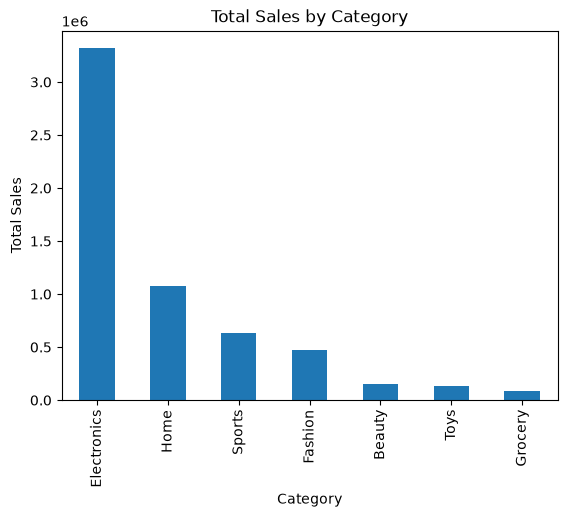

In [32]:
import matplotlib.pyplot as plt

category_sales = df.groupby('category')['total_amount'].sum().sort_values(ascending=False)

category_sales.plot(kind='bar')
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.show()

In [33]:
df.groupby('region')['total_amount'].sum().sort_values(ascending=False)

region
South      1298096.07
North      1264008.35
West       1186350.50
East       1176334.75
Central     940503.38
Name: total_amount, dtype: float64

In [34]:
df.groupby('region')['total_amount'].mean().sort_values(ascending=False)

region
West       174.258299
South      171.162456
East       170.384523
Central    166.992788
North      166.931900
Name: total_amount, dtype: float64

In [35]:
df['region'].value_counts()

region
South      7584
North      7572
East       6904
West       6808
Central    5632
Name: count, dtype: int64

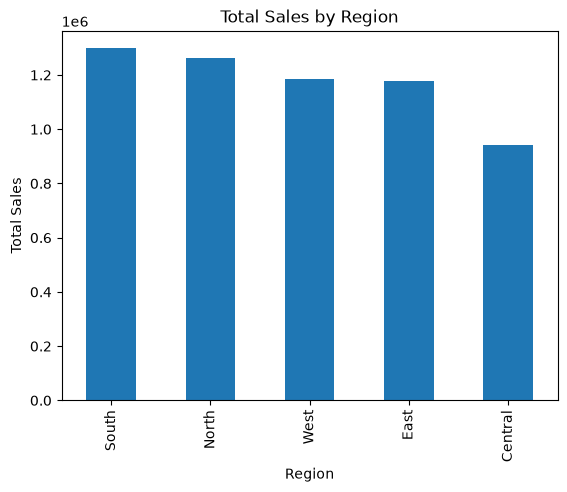

In [36]:
region_sales = df.groupby('region')['total_amount'].sum().sort_values(ascending=False)

region_sales.plot(kind='bar')
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.show()

In [37]:
df.groupby(['year', 'quarter'])['total_amount'].sum()

year  quarter
2023  3          151135.60
      4          758406.68
2024  1          693956.35
      2          764627.27
      3          684856.50
      4          787657.50
2025  1          679075.21
      2          760327.77
      3          585250.17
Name: total_amount, dtype: float64

In [39]:
df.groupby(['year', 'quarter']).size()

year  quarter
2023  3           876
      4          4352
2024  1          4167
      2          4244
      3          4297
      4          4425
2025  1          4260
      2          4355
      3          3524
dtype: int64

In [40]:
df[df['year'] == 2024].groupby(['quarter', 'category'])['total_amount'].sum()

quarter  category   
1        Beauty          19545.23
         Electronics    383271.54
         Fashion         55789.11
         Grocery          9520.85
         Home           128413.59
         Sports          81976.24
         Toys            15439.79
2        Beauty          19801.53
         Electronics    444684.23
         Fashion         60235.95
         Grocery         10121.53
         Home           134300.97
         Sports          78279.91
         Toys            17203.15
3        Beauty          19810.40
         Electronics    364991.08
         Fashion         58196.30
         Grocery         10743.61
         Home           144291.22
         Sports          68796.02
         Toys            18027.87
4        Beauty          18885.13
         Electronics    478108.34
         Fashion         66118.15
         Grocery          9916.60
         Home           117244.47
         Sports          80553.44
         Toys            16831.37
Name: total_amount, dtype: 

In [41]:
df[(df['year'] == 2024) & (df['category'] == 'Electronics')].groupby('quarter').agg(
    orders=('order_id', 'count'),
    average_order_value=('total_amount', 'mean')
)

,orders,average_order_value
quarter,,
1,739,518.635372
2,763,582.810262
3,721,506.228960
4,863,554.007346


In [42]:
electronics_2024 = df[
    (df['year'] == 2024) &
    (df['category'] == 'Electronics')
]

electronics_2024.groupby('quarter').agg(
    average_price=('price', 'mean'),
    average_quantity=('quantity', 'mean')
)

,average_price,average_quantity
quarter,,
1,356.828755,1.504736
2,380.472412,1.554391
3,371.867989,1.470180
4,369.273152,1.570104


In [43]:
electronics_2024.groupby('quarter')['discount'].mean()

quarter
1    0.053248
2    0.051048
3    0.050277
4    0.054693
Name: discount, dtype: float64

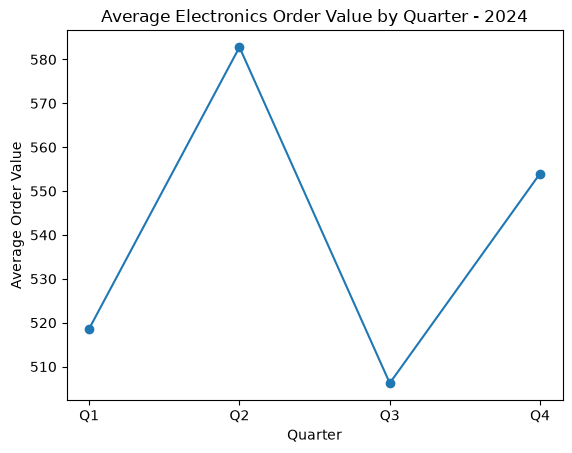

In [44]:
electronics_aov = electronics_2024.groupby('quarter')['total_amount'].mean()

electronics_aov.plot(kind='line', marker='o')
plt.title('Average Electronics Order Value by Quarter - 2024')
plt.xlabel('Quarter')
plt.ylabel('Average Order Value')
plt.xticks([1, 2, 3, 4], ['Q1', 'Q2', 'Q3', 'Q4'])
plt.show()

In [45]:
df.groupby('category')['profit_margin'].mean().sort_values(ascending=False)

category
Electronics    55.723587
Home           47.864717
Sports         38.485114
Fashion        20.597162
Beauty         11.990395
Toys            7.927773
Grocery        -2.264160
Name: profit_margin, dtype: float64

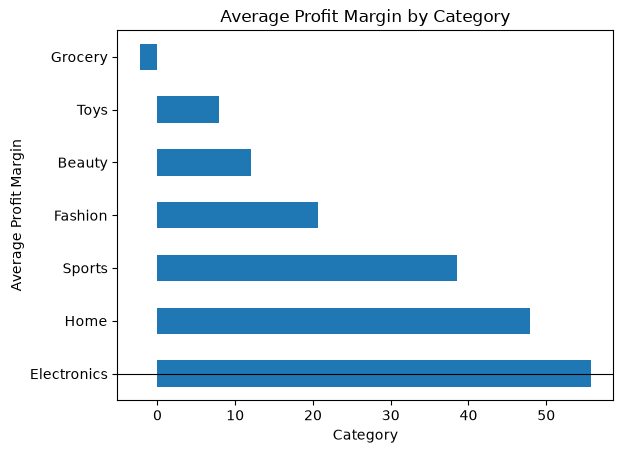

In [47]:
profitability = df.groupby('category')['profit_margin'].mean().sort_values(ascending=False)

profitability.plot(kind='barh')
plt.title('Average Profit Margin by Category')
plt.xlabel('Category')
plt.ylabel('Average Profit Margin')
plt.axhline(0, color='black', linewidth=0.8)
plt.show()

In [48]:
grocery = df[df['category'] == 'Grocery']

grocery['price'].describe()

count    4058.000000
mean       14.264872
std        13.166636
min         1.010000
25%         4.740000
50%        10.320000
75%        19.335000
max       141.050000
Name: price, dtype: float64

In [49]:
grocery['price_group'] = pd.cut(
    grocery['price'],
    bins=[0, 5, 10, 20, 50, 100, 150],
    labels=['0-5', '5-10', '10-20', '20-50', '50-100', '100-150']
)

grocery.groupby('price_group', observed=True)['profit_margin'].mean()

price_group
0-5        -1.946735
5-10       -2.587613
10-20      -2.762016
20-50      -2.024276
50-100      0.224286
100-150    18.036667
Name: profit_margin, dtype: float64

In [50]:
grocery['price_group'].value_counts().sort_index()

price_group
0-5        1081
5-10        905
10-20      1101
20-50       877
50-100       91
100-150       3
Name: count, dtype: int64

In [52]:
grocery['shipping_to_price'] = grocery['shipping_cost'] / grocery['price']

In [53]:
grocery[['price', 'shipping_cost', 'shipping_to_price']].head()

,price,shipping_cost,shipping_to_price
1,24.73,4.60,0.186009
9,10.91,2.76,0.252979
12,10.56,4.99,0.472538
28,20.97,4.61,0.219838
31,10.32,1.24,0.120155


In [54]:
grocery.groupby('price_group', observed=True)['shipping_to_price'].mean()

price_group
0-5        0.847785
5-10       0.474005
10-20      0.314094
20-50      0.188264
50-100     0.106589
100-150    0.071461
Name: shipping_to_price, dtype: float64

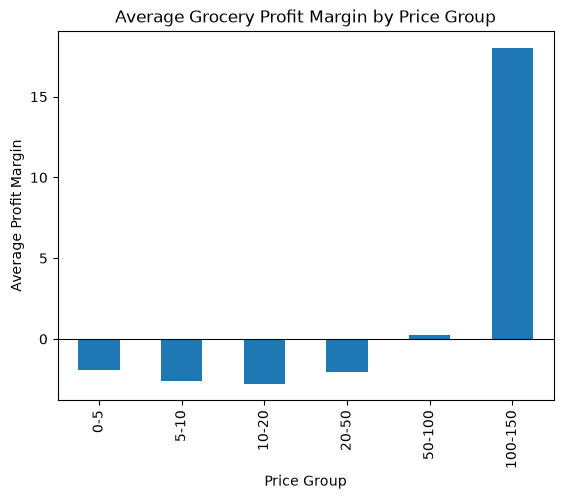

In [55]:
grocery_profit = grocery.groupby(
    'price_group', observed=True
)['profit_margin'].mean()

grocery_profit.plot(kind='bar')
plt.title('Average Grocery Profit Margin by Price Group')
plt.xlabel('Price Group')
plt.ylabel('Average Profit Margin')
plt.axhline(0, color='black', linewidth=0.8)
plt.show()

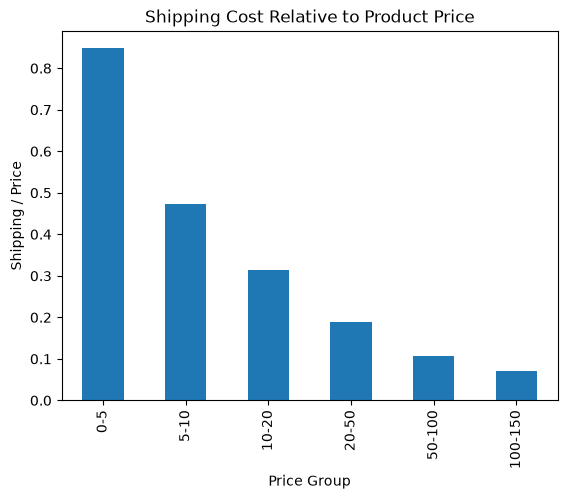

In [56]:
shipping_ratio = grocery.groupby(
    'price_group', observed=True
)['shipping_to_price'].mean()

shipping_ratio.plot(kind='bar')
plt.title('Shipping Cost Relative to Product Price')
plt.xlabel('Price Group')
plt.ylabel('Shipping / Price')
plt.show()

### Grocery Profitability Investigation

Grocery products are generally low-priced, with 97.7% of orders priced below 50. These lower-priced groups also have negative average profit margins.

The analysis also shows that shipping costs represent a much larger share of product prices for lower-priced Grocery products. The average shipping-to-price ratio decreases as product price increases.

This suggests that the relatively high shipping burden on low-priced Grocery products is associated with their negative profitability.

## Key Findings

### 1. Electronics was the strongest-performing category
Electronics generated the highest total sales and average order value among all categories. It also recorded the highest average profit margin, making it the strongest-performing category in both sales and profitability.

### 2. The South region generated the highest total sales
The South region recorded the highest total sales, largely supported by its high order volume. However, the West region had the highest average order value, showing that higher sales can be influenced by both the number of orders and the amount spent per order.

### 3. The 2024 Q2 to Q3 sales decline was mainly associated with weaker Electronics performance
Overall sales declined from 2024 Q2 to Q3 despite a slight increase in the total number of orders. The decline was primarily associated with weaker Electronics performance.

Electronics orders decreased from 763 to 721, while average order value fell from 582.81 to 506.23. Average product price and quantity per order also decreased slightly, while average discounts remained broadly stable.

This suggests that the decline in Electronics sales was associated with both fewer orders and lower spending per order.

### 4. Grocery was the weakest category in terms of profitability
Grocery was the only category with a negative average profit margin. Further investigation showed that 97.7% of Grocery orders were priced below 50, and these lower-priced groups generally had negative average profit margins.

### 5. Lower-priced Grocery products had a higher relative shipping burden
The analysis showed that shipping costs represented a much larger share of the product price for lower-priced Grocery products. The shipping-to-price ratio decreased as product price increased.

This suggests that the relatively high shipping burden on lower-priced Grocery products is associated with their negative profitability.

## Recommendations

Based on the findings from the analysis, the following actions could help improve sales performance and profitability:

1. **Prioritize the Electronics category**
   Electronics generated the highest sales, average order value, and average profit margin. The business could prioritize this category through effective product selection, inventory planning, and targeted promotions.

2. **Investigate the factors behind the Electronics sales decline**
   Since the 2024 Q2 to Q3 decline was associated with fewer Electronics orders and lower average order value, the business should investigate changes in product availability, pricing, customer demand, and purchasing patterns during this period.

3. **Review the pricing and shipping strategy for Grocery**
   Grocery recorded negative average profitability, particularly among lower-priced products. The business could review pricing, shipping policies, and order-size requirements to reduce the relative shipping burden on low-value orders.

4. **Encourage higher-value orders**
   Since average order value varies across categories and regions, the business could explore product bundles, cross-selling, or minimum-order incentives to encourage customers to place higher-value orders.

5. **Monitor profitability alongside sales**
   The business should evaluate both sales and profitability when assessing category performance. High sales alone do not necessarily indicate strong financial performance.

## Conclusion

This analysis examined e-commerce sales and profitability across different categories, regions, and time periods to understand the factors associated with business performance.

The analysis found that Electronics was the strongest-performing category, with the highest sales, average order value, and average profit margin. The South region generated the highest total sales, while the West had the highest average order value.

The analysis also identified a decline in sales from 2024 Q2 to Q3. Further investigation showed that this decline was primarily associated with weaker Electronics performance, as both Electronics order volume and average order value decreased.

Grocery presented a different challenge, with negative average profitability. Further investigation showed that most Grocery orders were low-priced and that shipping costs represented a relatively large share of the product price for these lower-priced orders.

Overall, the analysis demonstrates the importance of looking beyond total sales and examining factors such as order volume, average order value, pricing, and profitability to understand e-commerce performance and identify areas for improvement.